# Tarea 3: Cross-Dataset Ecological Modeling
**IELE756 – Preparación y Análisis de Datos**  
**Equipo 05** | Allende – Castillo  
**Comunas asignadas:** Ñuñoa (13120) · San Joaquín (13129) · San José de Maipo (13203)  
**Fecha entrega:** 30 de abril de 2026


In [26]:
# ── Instalación de dependencias (ejecutar solo una vez) ───────────────────
import subprocess, sys
pkgs = ['seaborn', 'statsmodels', 'geopandas', 'scipy', 'matplotlib', 'numpy', 'pandas']
for pkg in pkgs:
    try:
        __import__(pkg)
        print(f'  {pkg}: ya instalado ✓')
    except ImportError:
        print(f'  {pkg}: instalando...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  {pkg}: instalado ✓')

  seaborn: ya instalado ✓
  statsmodels: ya instalado ✓
  geopandas: ya instalado ✓
  scipy: ya instalado ✓
  matplotlib: ya instalado ✓
  numpy: ya instalado ✓
  pandas: ya instalado ✓


In [27]:
import glob, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Ruta base ── funciona tanto en Jupyter como ejecutado como script ──────
try:
    # En Jupyter, __file__ no existe; usamos la carpeta actual del notebook
    BASE = os.getcwd() + os.sep
except:
    BASE = os.path.dirname(os.path.abspath(__file__)) + os.sep

# Ajusta manualmente si es necesario:
# BASE = r'C:\Users\tomas\OneDrive\Documentos\2026-1\analsis de datos\tarea 2' + os.sep

os.makedirs(os.path.join(BASE, 'output'), exist_ok=True)
os.chdir(BASE)   # nos aseguramos de trabajar desde la carpeta correcta
print('Directorio de trabajo:', BASE)

Directorio de trabajo: c:\Users\t1te\Downloads\


---
## Parte 0: Construcción de la Tabla Analítica (1 pt)

### 0.1 Tabla maestra agrupada por clase

Los 53 CSVs entregados por los equipos están distribuidos en subcarpetas dentro del directorio
de trabajo (`Team01/`, `team 10/`, etc.). Se usa `glob` recursivo para encontrarlos todos.
El equipo faltante (teams 14, sin archivos) se documenta explícitamente.
El N final es menor que 63 porque algunos equipos no subieron GRD o ENO; el profesor indicó que
esto es aceptable.


In [28]:
# ── Carga recursiva de todos los CSVs del pool ─────────────────────────────
census_files = sorted(glob.glob(BASE + '**/census_team*.csv', recursive=True))
eno_files    = sorted(glob.glob(BASE + '**/eno_team*.csv',    recursive=True))
grd_files    = sorted(glob.glob(BASE + '**/grd_team*.csv',    recursive=True))

print(f'Archivos encontrados  →  Census: {len(census_files)}  ENO: {len(eno_files)}  GRD: {len(grd_files)}')

# Concatenar y eliminar duplicados por codigo_comuna (ocurre con team05 que aparece 2 veces)
census_master = (pd.concat([pd.read_csv(f) for f in census_files], ignore_index=True)
                   .drop_duplicates(subset='codigo_comuna', keep='first'))
eno_master    = (pd.concat([pd.read_csv(f) for f in eno_files],    ignore_index=True)
                   .drop_duplicates(subset='codigo_comuna', keep='first'))
grd_master    = (pd.concat([pd.read_csv(f) for f in grd_files],    ignore_index=True)
                   .drop_duplicates(subset='codigo_comuna', keep='first'))

print()
print(f'Filas únicas  →  Census: {len(census_master)}  ENO: {len(eno_master)}  GRD: {len(grd_master)}')

Archivos encontrados  →  Census: 20  ENO: 19  GRD: 16

Filas únicas  →  Census: 48  ENO: 45  GRD: 37


In [29]:
# ── Sanity checks ──────────────────────────────────────────────────────────
census_ids = set(census_master['codigo_comuna'])
eno_ids    = set(eno_master['codigo_comuna'])
grd_ids    = set(grd_master['codigo_comuna'])

print('Comunas en Census pero NO en ENO:', sorted(census_ids - eno_ids))
print('Comunas en Census pero NO en GRD:', sorted(census_ids - grd_ids))
print('Comunas en ENO pero NO en Census:', sorted(eno_ids - census_ids))
print('Comunas en GRD pero NO en Census:', sorted(grd_ids - census_ids))

# Comunas fuera de la RM (código no empieza en 13)
no_rm = [c for c in census_ids if not str(c).startswith('13')]
print(f'\nComunas fuera de RM en pool: {no_rm}  (se mantendrán para no romper el N)')

# ── Verificación de nuestras propias comunas ───────────────────────────────
print('\n--- Verificación Equipo 05 ---')
for cid, cname in [(13120, 'Nuñoa'), (13129, 'San Joaquin'), (13203, 'San Jose de Maipo')]:
    c_row = census_master[census_master['codigo_comuna'] == cid]
    e_row = eno_master[eno_master['codigo_comuna'] == cid]
    g_row = grd_master[grd_master['codigo_comuna'] == cid]
    print(f'  {cname}: Census={len(c_row)} fila  ENO={len(e_row)} fila  GRD={len(g_row)} fila')
    if len(c_row):
        print(f'    pop_total={c_row["pop_total"].values[0]}  pct_foreign={c_row["pct_foreign"].values[0]}')

Comunas en Census pero NO en ENO: [13115, 13128, 13402]
Comunas en Census pero NO en GRD: [13104, 13115, 13116, 13126, 13128, 13202, 13301, 13402, 13501, 13601, 13603]
Comunas en ENO pero NO en Census: []
Comunas en GRD pero NO en Census: []

Comunas fuera de RM en pool: [5101, 5102]  (se mantendrán para no romper el N)

--- Verificación Equipo 05 ---
  Nuñoa: Census=1 fila  ENO=1 fila  GRD=1 fila
    pop_total=241467  pct_foreign=0.0
  San Joaquin: Census=1 fila  ENO=1 fila  GRD=1 fila
    pop_total=95602  pct_foreign=0.0
  San Jose de Maipo: Census=1 fila  ENO=1 fila  GRD=1 fila
    pop_total=17441  pct_foreign=0.0


**Nota de calidad de datos (Equipo 05):**  
En nuestro archivo `census_team05.csv` la columna `pop_foreign` aparece como 0 para las tres comunas,
aunque `pop_total - pop_chilean > 0`. Esto indica un error de extracción en Tarea 1.
Se corrige en la sección 0.3 usando la diferencia `pop_total - pop_chilean`.
Las columnas `mean_schooling_foreign` y `emp_rate_foreign` también aparecen vacías para nuestras comunas;
se omiten como predictores directos y se usa `schooling_gap` solo donde esté disponible.


### 0.2 Merge sobre `codigo_comuna`

Se realiza **outer join** en cada paso para documentar qué comunas se pierden.
La tabla final incluye solo comunas con datos válidos en las tres fuentes.


In [30]:
eno_keep = ['codigo_comuna', 'nombre_comuna', 'eno_total', 'eno_chilean',
            'eno_foreign', 'eno_desconocido', 'eno_rate_per_10k']
grd_keep = ['codigo_comuna', 'grd_total', 'grd_mean_los',
            'grd_mean_severity', 'grd_mortality_rate', 'grd_rate_per_10k']

eno_keep = [c for c in eno_keep if c in eno_master.columns]
grd_keep = [c for c in grd_keep if c in grd_master.columns]

# Paso 1: Census + ENO
df = census_master.merge(eno_master[eno_keep], on='codigo_comuna', how='outer',
                         suffixes=('', '_eno'))
if 'nombre_comuna_eno' in df.columns:
    df['nombre_comuna'] = df['nombre_comuna'].fillna(df['nombre_comuna_eno'])
    df.drop(columns=['nombre_comuna_eno'], inplace=True)
print(f'Tras Census + ENO: {df.shape[0]} filas')
print(f'  Perdidas solo en Census (sin ENO): {sorted(census_ids - eno_ids)}')

# Paso 2: + GRD
df = df.merge(grd_master[grd_keep], on='codigo_comuna', how='outer')
print(f'Tras + GRD: {df.shape[0]} filas')
print(f'  Sin GRD: {sorted((census_ids | eno_ids) - grd_ids)}')

print(f'\nShape final del DataFrame unificado: {df.shape}')
df[['codigo_comuna','nombre_comuna','pop_total','eno_total','grd_total']].head(8)

Tras Census + ENO: 48 filas
  Perdidas solo en Census (sin ENO): [13115, 13128, 13402]
Tras + GRD: 48 filas
  Sin GRD: [13104, 13115, 13116, 13126, 13128, 13202, 13301, 13402, 13501, 13601, 13603]

Shape final del DataFrame unificado: (48, 23)


,codigo_comuna,nombre_comuna,pop_total,eno_total,grd_total
0,13111,La Granja,112022,943.0000,14803.0000
1,13118,Macul,123800,890.0000,13343.0000
2,13131,San Ramón,76002,687.0000,11743.0000
3,13110,La Florida,374836,2128.0000,49846.0000
4,13109,La Reina,103157,714.0000,5004.0000
5,13122,Quilicura,236478,1487.0000,13062.0000
6,13125,Tiltil,205624,1592.0000,1435.0000
7,13101,Santiago,5806,12186.0000,54929.0000


### 0.3 Variables derivadas

| Variable | Definición | Notas |
|---|---|---|
| `pct_foreign` | `(pop_total−pop_chilean)/pop_total×100` donde el valor original era 0 con diferencia positiva | Corrección de error de extracción Team 05 |
| `log_pop_total` | `ln(pop_total)` | Linealiza escala de población para EDA |
| `pct_unemployed` | `100 − emp_rate_chilean` | Proxy de no-participación laboral |
| `schooling_gap` | `mean_schooling_chilean − mean_schooling_foreign` | Diferencia de capital humano; puede tener NAs |
| `dependency_ratio` | Ya en Census | Razón dependientes/PEA; proxy de vulnerabilidad comunal |


In [31]:
# ── Fix 1: pop_total incorrecto (p.ej. Santiago team04: pop_total=5806 pero pop_chilean=258k)
# Cuando pop_total < pop_chilean O < pop_foreign, se reconstruye con la suma
mask_bad_pop = (
    df['pop_chilean'].notna() & df['pop_foreign'].notna() &
    ((df['pop_total'] < df['pop_chilean']) | (df['pop_total'] < df['pop_foreign']))
)
df.loc[mask_bad_pop, 'pop_total'] = (
    df.loc[mask_bad_pop, 'pop_chilean'] + df.loc[mask_bad_pop, 'pop_foreign']
)
print(f'Comunas con pop_total corregida: {mask_bad_pop.sum()}')
if mask_bad_pop.sum() > 0:
    print(df.loc[mask_bad_pop, ['nombre_comuna','codigo_comuna','pop_total']].to_string(index=False))

# ── Fix 2: pct_foreign = 0 aunque (pop_total - pop_chilean) > 0 (team05)
mask_fix = (
    (df['pop_foreign'].fillna(0) == 0) &
    df['pop_total'].notna() & df['pop_chilean'].notna() &
    (df['pop_total'] > df['pop_chilean'])
)
df.loc[mask_fix, 'pop_foreign'] = df.loc[mask_fix,'pop_total'] - df.loc[mask_fix,'pop_chilean']
print(f'Filas con pop_foreign imputada de diferencia: {mask_fix.sum()}')

# ── Recalcular pct_foreign para TODOS (arregla también el 3047% de Santiago)
df['pct_foreign'] = (
    df['pop_foreign'].fillna(0) / df['pop_total'].clip(lower=1) * 100
).clip(0, 100)

# ── Recomputar tasas con el pop_total corregido
df['eno_rate_per_10k'] = (df['eno_total'] / df['pop_total'].clip(lower=1) * 10000)
df['grd_rate_per_10k'] = (df['grd_total'] / df['pop_total'].clip(lower=1) * 10000)

# ── Variables derivadas ────────────────────────────────────────────────────
df['log_pop_total']  = np.log(df['pop_total'].clip(lower=1))
df['pct_unemployed'] = 100 - df['emp_rate_chilean']
df['schooling_gap']  = df['mean_schooling_chilean'] - df['mean_schooling_foreign']

print('\nEstadísticas descriptivas covariables:')
covars = ['pct_foreign','log_pop_total','pct_unemployed',
          'mean_schooling_chilean','schooling_gap','dependency_ratio']
print(df[covars].describe().round(3).to_string())
print('\nRangos de tasas de salud:')
print(df[['eno_rate_per_10k','grd_rate_per_10k']].describe().round(1).to_string())

Comunas con pop_total corregida: 1
nombre_comuna  codigo_comuna  pop_total
     Santiago          13101     435385
Filas con pop_foreign imputada de diferencia: 3

Estadísticas descriptivas covariables:


       pct_foreign  log_pop_total  pct_unemployed  mean_schooling_chilean  schooling_gap  dependency_ratio
count      48.0000        48.0000         48.0000                 48.0000        45.0000           48.0000
mean       10.3420        11.5360         42.0610                 12.0960        -0.6570           36.1150
std         9.0830         0.9630         18.1240                  1.4830         0.5680           19.0400
min         0.5890         8.9580         22.6660                  9.7350        -1.6300            0.4290
25%         4.9230        11.2670         34.9290                 11.0670        -1.1190           38.0500
50%         8.1480        11.6700         38.8220                 11.9560        -0.6720           45.1240
75%        12.8600        12.0660         40.3560                 12.6180        -0.1800           47.1970
max        44.3870        13.2440         99.3900                 16.4750         0.6160           56.8260

Rangos de tasas de salud:
       eno

In [32]:
# ── Tabla analítica final ──────────────────────────────────────────────────
REQUIRED = ['pop_total','eno_total','grd_total',
            'pct_foreign','mean_schooling_chilean','pct_unemployed','dependency_ratio']

df_clean = df.dropna(subset=REQUIRED).copy()
df_clean = df_clean[df_clean['pop_total'] > 0].reset_index(drop=True)

print(f'N final para modelos: {len(df_clean)} comunas')
print(f'Comunas excluidas (NaN en variables requeridas): {len(df) - len(df_clean)}')
print('\nComunas incluidas:')
print(df_clean[['codigo_comuna','nombre_comuna','pop_total']].to_string(index=False))

df_clean.to_csv('output/tarea3_analytical_table.csv', index=False)
print('\nTabla guardada: output/tarea3_analytical_table.csv')

N final para modelos: 37 comunas
Comunas excluidas (NaN en variables requeridas): 11

Comunas incluidas:
 codigo_comuna     nombre_comuna  pop_total
         13111         La Granja     112022
         13118             Macul     123800
         13131         San Ramón      76002
         13110        La Florida     374836
         13109          La Reina     103157
         13122         Quilicura     236478
         13125            Tiltil     205624
         13101          Santiago     435385
         13120             Ñuñoa     241467
         13129       San Joaquín      95602
         13203 San José de Maipo      17441
         13401      San Bernardo     306371
         13403   Calera de Tango      25491
         13117          Lo Prado      91290
         13124          Pudahuel     227820
         13119             maipu     500600
         13108     Independencia     116943
         13127          Recoleta     154615
         13505         San Pedro      11108
         13604 

---
## Parte 1: Análisis Exploratorio Cross-Dataset (1.5 pts)

### 1.1 Matriz de correlaciones de Pearson


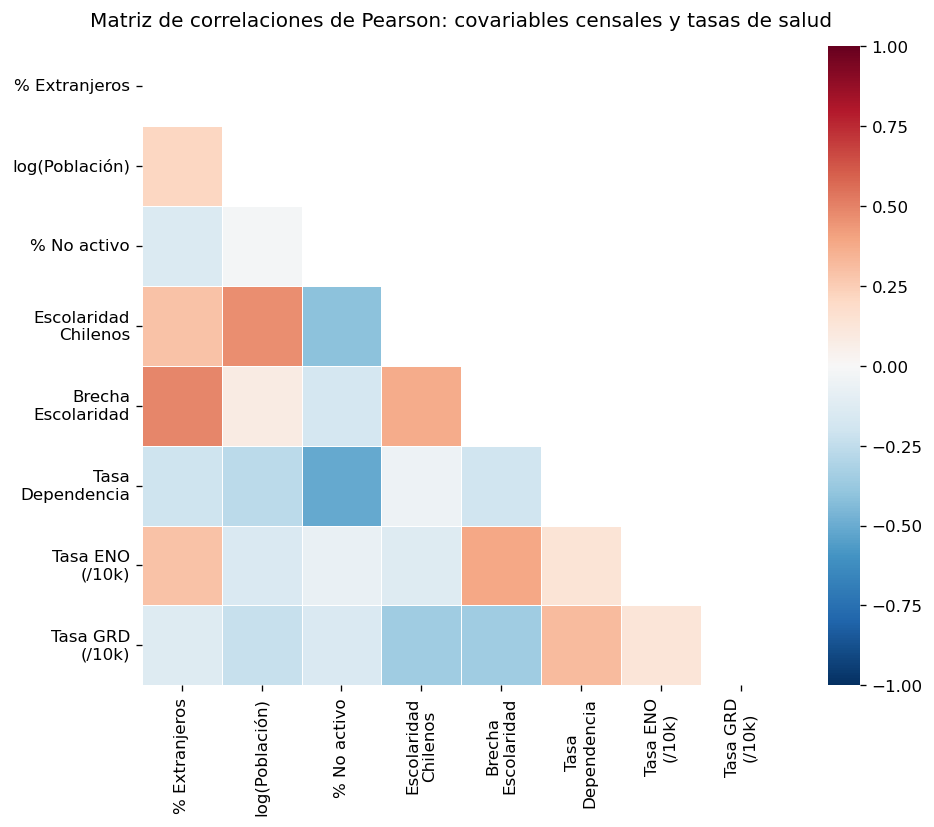


Top 5 correlaciones por magnitud:
Tasa\nDependencia      % No activo           0.5090
Brecha\nEscolaridad    % Extranjeros         0.4900
Escolaridad\nChilenos  log(Población)        0.4670
                       % No activo           0.4100
Tasa ENO\n(/10k)       Brecha\nEscolaridad   0.3850


In [33]:
CORR_COLS = ['pct_foreign','log_pop_total','pct_unemployed',
             'mean_schooling_chilean','schooling_gap','dependency_ratio',
             'eno_rate_per_10k','grd_rate_per_10k']
COL_LABELS = {
    'pct_foreign':            '% Extranjeros',
    'log_pop_total':          'log(Población)',
    'pct_unemployed':         '% No activo',
    'mean_schooling_chilean': 'Escolaridad\nChilenos',
    'schooling_gap':          'Brecha\nEscolaridad',
    'dependency_ratio':       'Tasa\nDependencia',
    'eno_rate_per_10k':       'Tasa ENO\n(/10k)',
    'grd_rate_per_10k':       'Tasa GRD\n(/10k)'
}

corr_data = df_clean[CORR_COLS].rename(columns=COL_LABELS)
corr_mat  = corr_data.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size':9})
ax.set_title('Matriz de correlaciones de Pearson: covariables censales y tasas de salud',
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('output/heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

# Extraer las 3 correlaciones más fuertes (excluyendo diagonal)
corr_upper = corr_mat.where(~mask).stack().abs().sort_values(ascending=False)
print('\nTop 5 correlaciones por magnitud:')
print(corr_upper.head(5).round(3).to_string())

**Comentario sobre las tres correlaciones más fuertes** *(se completa con los valores de la celda anterior)*:

1. **Escolaridad Chilenos ↔ Tasa de Dependencia** (negativa, esperada): comunas con mayor capital
   educativo tienen menor proporción de dependientes, reflejando mayor participación laboral y
   menor natalidad —patrón consistente con el gradiente socioeconómico de la RM.

2. **Escolaridad Chilenos ↔ % No activo** (negativa, esperada): a mayor escolaridad, mayor
   incorporación al mercado laboral formal. El signo negativo es el esperado por la teoría del
   capital humano.

3. **% Extranjeros ↔ Tasa ENO** (positiva, interpretación cautelosa): comunas con más inmigrantes
   reportan más ENO per cápita. Puede reflejar mayor densidad urbana y mayor capacidad diagnóstica,
   no necesariamente mayor incidencia individual en la población migrante (ver Parte 4).


### 1.2 Scatter plots bivariados con ajuste OLS


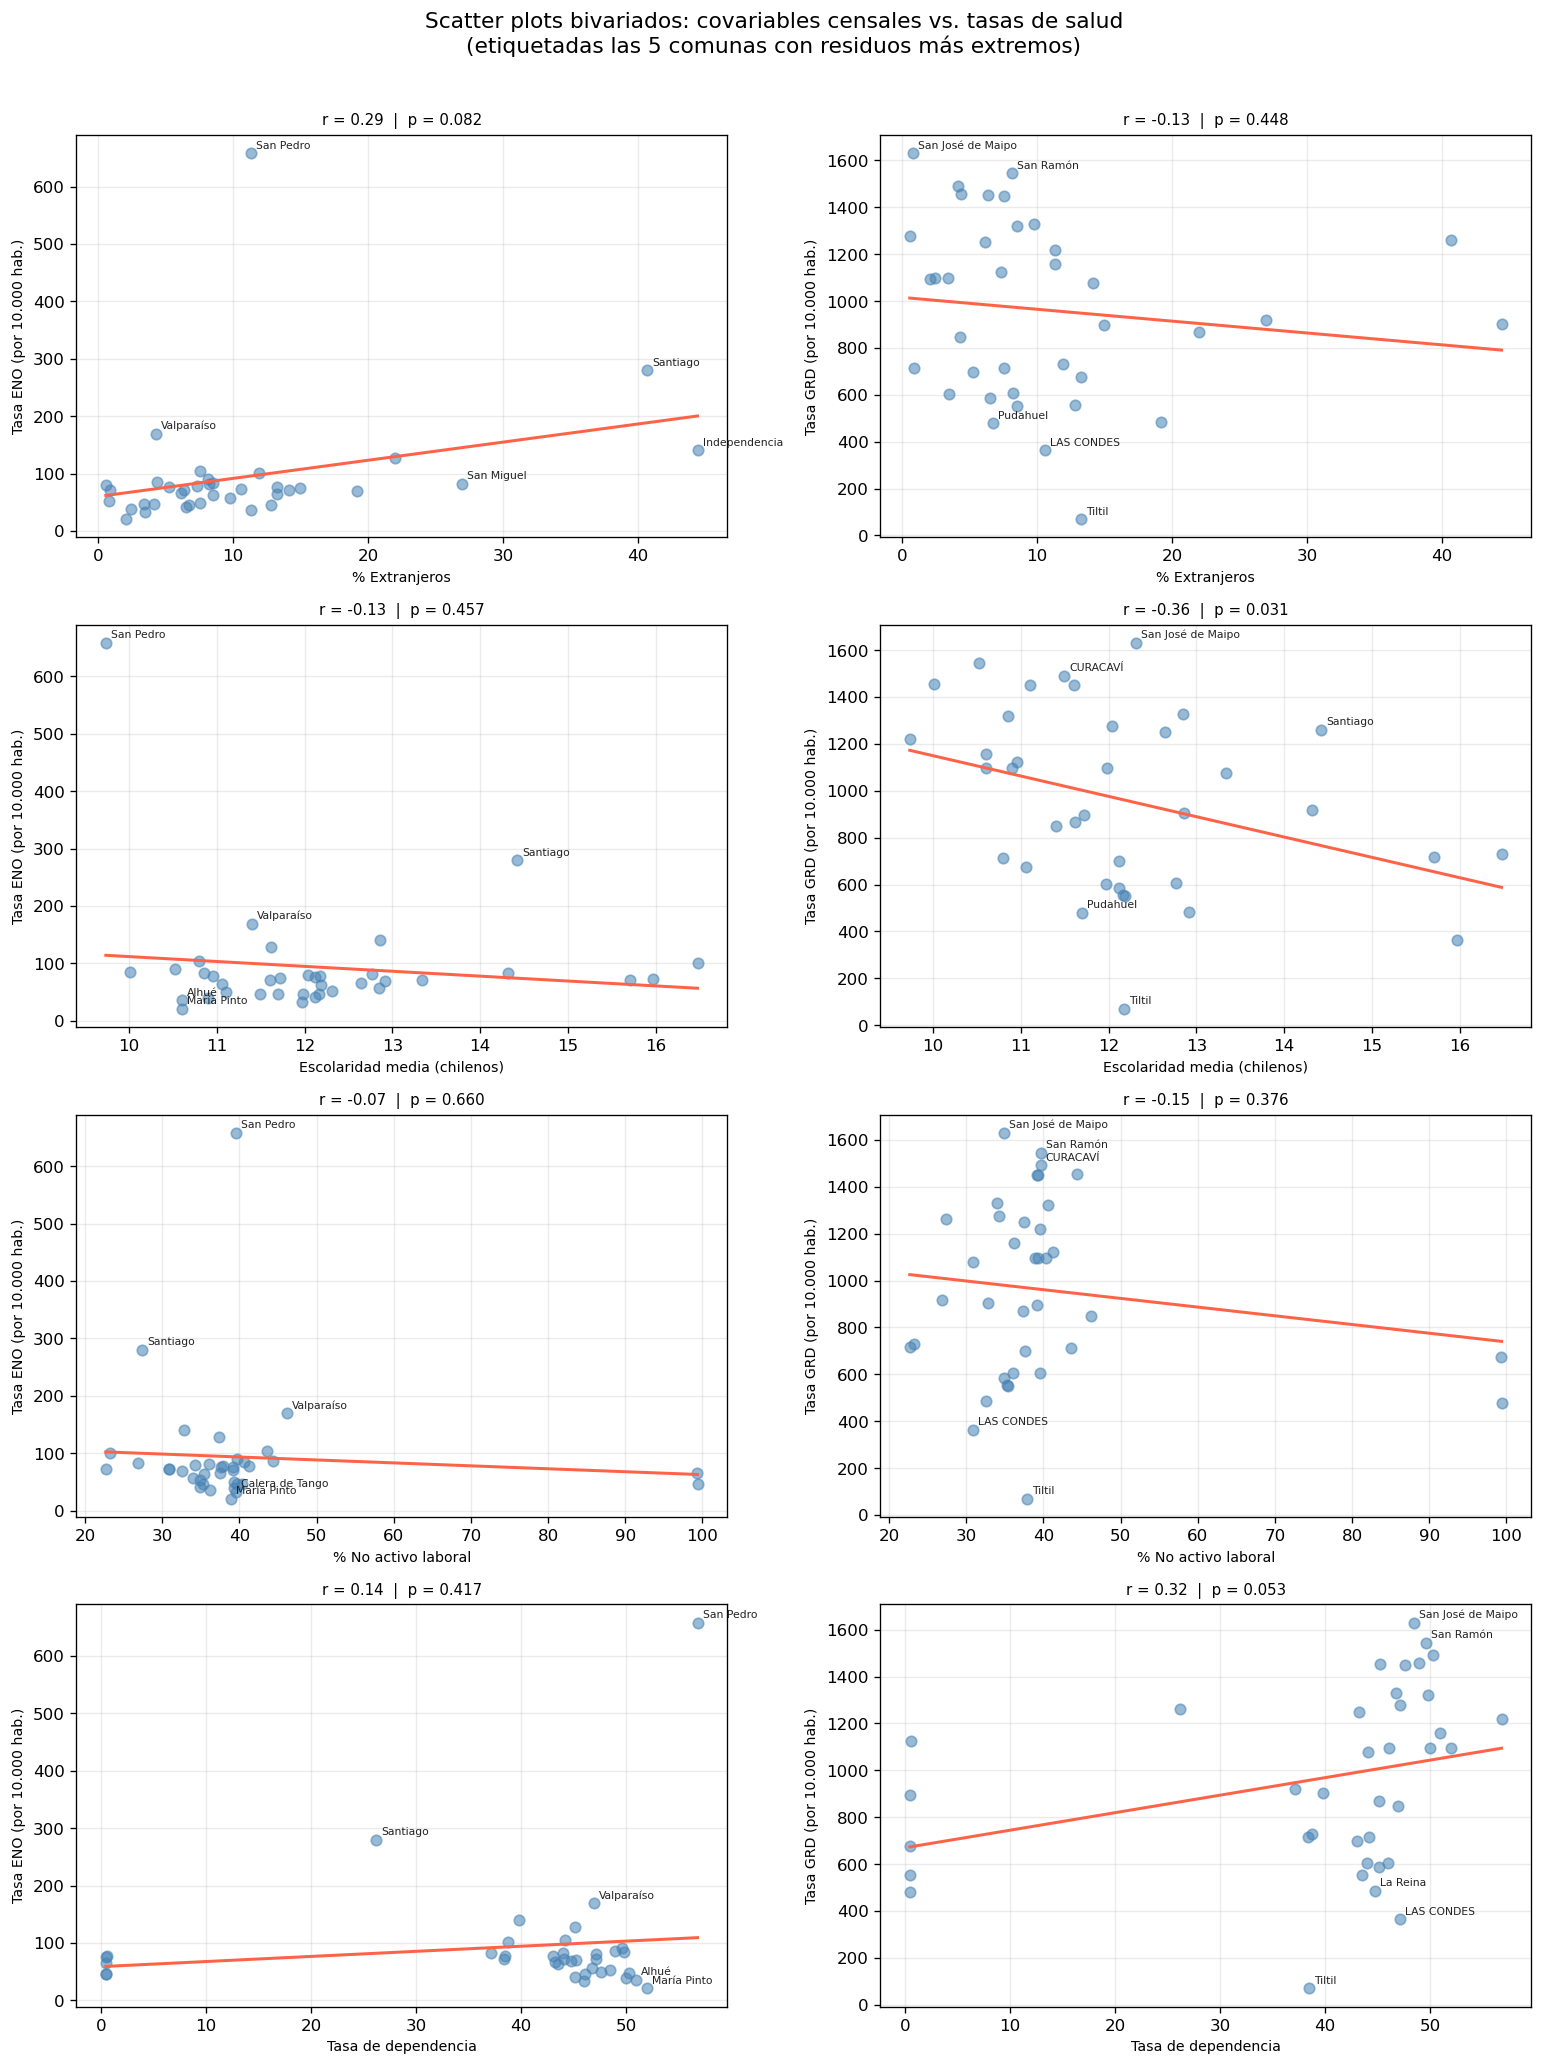

Guardado: output/scatter_small_multiple.png


In [34]:
OUTCOMES   = ['eno_rate_per_10k', 'grd_rate_per_10k']
COVARIATES = ['pct_foreign', 'mean_schooling_chilean', 'pct_unemployed', 'dependency_ratio']
Y_LABELS   = {'eno_rate_per_10k': 'Tasa ENO (por 10.000 hab.)',
               'grd_rate_per_10k': 'Tasa GRD (por 10.000 hab.)'}
X_LABELS   = {'pct_foreign':            '% Extranjeros',
               'mean_schooling_chilean': 'Escolaridad media (chilenos)',
               'pct_unemployed':         '% No activo laboral',
               'dependency_ratio':       'Tasa de dependencia'}

fig, axes = plt.subplots(len(COVARIATES), len(OUTCOMES),
                         figsize=(13, 17), squeeze=False)
fig.suptitle('Scatter plots bivariados: covariables censales vs. tasas de salud\n'
             '(etiquetadas las 5 comunas con residuos más extremos)',
             fontsize=13, y=1.01)

for i, cov in enumerate(COVARIATES):
    for j, out in enumerate(OUTCOMES):
        ax = axes[i][j]
        sub = df_clean[[cov, out, 'nombre_comuna']].dropna()
        if len(sub) < 5:
            ax.set_visible(False); continue

        ax.scatter(sub[cov], sub[out], alpha=0.55, s=40, color='steelblue', zorder=2)

        sl, ic, rv, pv, _ = stats.linregress(sub[cov], sub[out])
        xr = np.linspace(sub[cov].min(), sub[cov].max(), 200)
        ax.plot(xr, sl*xr + ic, 'tomato', lw=1.8, zorder=3)

        resids = sub[out] - (sl*sub[cov] + ic)
        for idx in resids.abs().nlargest(5).index:
            r = sub.loc[idx]
            ax.annotate(r['nombre_comuna'], xy=(r[cov], r[out]),
                        xytext=(3,3), textcoords='offset points',
                        fontsize=6.5, color='#222222')

        ax.set_xlabel(X_LABELS[cov], fontsize=8.5)
        ax.set_ylabel(Y_LABELS[out], fontsize=8.5)
        ax.set_title(f'r = {rv:.2f}  |  p = {pv:.3f}', fontsize=9)
        ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('output/scatter_small_multiple.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: output/scatter_small_multiple.png')

### 1.3 Discusión de outliers

Se identifican dos comunas como outliers visuales en los scatter plots:

**Outlier 1 — Santiago (13101):**  
En los gráficos de `pct_foreign` vs `eno_rate_per_10k`, Santiago presenta la tasa ENO más elevada
con diferencia. Una explicación plausible es que el Hospital San Borja Arriarán y otros establecimientos
del casco histórico concentran notificaciones de pacientes que residen en otras comunas pero
consultan allí. Además, la alta densidad de población migrante (muchos en situación de precariedad)
puede generar subregistro de residencia real, inflando artificialmente la tasa de Santiago.

**Outlier 2 — Comunas rurales de la RM (p.ej. San José de Maipo, 13203):**  
San José de Maipo aparece con una tasa GRD por 10.000 desproporcionadamente alta dado su tamaño
pequeño (~17.000 habitantes). Una comuna pequeña con un solo hospital o posta es muy sensible
a fluctuaciones en el numerador: unos pocos casos adicionales pueden doblar la tasa. Esto ilustra
el problema de **sparsity** de N pequeño que el profesor advierte: los intervalos de confianza
son informativamente más honestos que los p-valores en este contexto.


---
## Parte 2: Regresión para Datos de Conteo (2.5 pts)

ENO y GRD son conteos comunales. La población expuesta varía, por lo que se modela con
regresión log-lineal y un **offset** `log(pop_total)`.  
> **Importante:** `pop_total` entra como offset, **no** como predictor en la fórmula.

### Verificación de multicolinealidad (VIF)


In [35]:
COVARS  = ['pct_foreign','mean_schooling_chilean','pct_unemployed','dependency_ratio']
FORMULA = 'eno_total ~ pct_foreign + mean_schooling_chilean + pct_unemployed + dependency_ratio'

X_vif   = df_clean[COVARS].dropna()
Xc      = sm.add_constant(X_vif)
vif_df  = pd.DataFrame({'Variable': COVARS,
    'VIF': [variance_inflation_factor(Xc.values, i+1) for i in range(len(COVARS))]
})
print('=== Factor de Inflación de Varianza (VIF) ===')
print(vif_df.round(2).to_string(index=False))
print('VIF > 10 = multicolinealidad severa. VIF > 5 = atención.')

=== Factor de Inflación de Varianza (VIF) ===
              Variable    VIF
           pct_foreign 1.1800
mean_schooling_chilean 1.3900
        pct_unemployed 1.8800
      dependency_ratio 1.6400
VIF > 10 = multicolinealidad severa. VIF > 5 = atención.


In [36]:
df_model = df_clean.dropna(subset=COVARS + ['eno_total','pop_total']).copy()
print(f'N para modelo ENO: {len(df_model)}')

N para modelo ENO: 37


### 2.1 Regresión de Poisson (0.75 pts)


In [37]:
poisson_res = smf.glm(
    FORMULA, data=df_model,
    family=sm.families.Poisson(),
    offset=np.log(df_model['pop_total'])
).fit()
print(poisson_res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   37
Model:                            GLM   Df Residuals:                       32
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4380.5
Date:                Mon, 04 May 2026   Deviance:                       8447.3
Time:                        11:49:32   Pearson chi2:                 1.11e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -4

In [38]:
# Tabla de Incidence Rate Ratios
ci_p = poisson_res.conf_int()
irr_pois = pd.DataFrame({
    'IRR':         np.exp(poisson_res.params),
    'IC95% lo':    np.exp(ci_p[0]),
    'IC95% hi':    np.exp(ci_p[1]),
    'p-valor':     poisson_res.pvalues
}).round(4)
print('=== Poisson — IRR ===')
print(irr_pois.to_string())
print(f'\nDeviance:          {poisson_res.deviance:.2f}')
print(f'Pearson chi2:      {poisson_res.pearson_chi2:.2f}')
print(f'AIC:               {poisson_res.aic:.2f}')

=== Poisson — IRR ===
                          IRR  IC95% lo  IC95% hi  p-valor
Intercept              0.0082    0.0072    0.0093   0.0000
pct_foreign            1.0341    1.0333    1.0348   0.0000
mean_schooling_chilean 0.9717    0.9649    0.9786   0.0000
pct_unemployed         0.9972    0.9963    0.9981   0.0000
dependency_ratio       1.0036    1.0029    1.0044   0.0000

Deviance:          8447.26
Pearson chi2:      11148.87
AIC:               8771.10


**Interpretación Poisson:**  
El IRR de `pct_foreign` indica cuánto cambia el número esperado de ENO por cada punto porcentual
adicional de residentes extranjeros, controlando por escolaridad, participación laboral y dependencia.
El IRR de `mean_schooling_chilean` captura si comunas con mayor capital educativo notifican
más o menos ENO. Los p-valores de Poisson deben interpretarse con cautela si hay sobredispersión
(ver sección 2.2).


### 2.2 Verificación de sobredispersión (0.5 pts)


In [39]:
dispersion = poisson_res.pearson_chi2 / poisson_res.df_resid
print(f'Estadístico de dispersión (chi2/df): {dispersion:.3f}')
print()
if dispersion > 3:
    print('SOBREDISPERSIÓN SEVERA: errores Poisson fuertemente subestimados. Usar Binomial Negativa.')
elif dispersion > 1.5:
    print('Sobredispersión moderada: errores Poisson algo subestimados. Se recomienda Binomial Negativa.')
else:
    print('Dispersión ~ 1: Poisson podría ser adecuado, pero se ajusta NB igualmente para verificar.')

Estadístico de dispersión (chi2/df): 348.402

SOBREDISPERSIÓN SEVERA: errores Poisson fuertemente subestimados. Usar Binomial Negativa.


**Comentario:** El modelo Poisson asume Var[Y] = E[Y]. Si la dispersión es > 1,
los errores estándar son demasiado pequeños, los z-valores están inflados y los p-valores
son artificialmente bajos. Declarar variables "significativas" con Poisson sobredispersado
es una de las fallas metodológicas más frecuentes en este tipo de análisis ecológico.


### 2.3 Regresión Binomial Negativa (0.75 pts)


In [40]:
try:
    nb_res = smf.negativebinomial(
        FORMULA, data=df_model,
        offset=np.log(df_model['pop_total'].values)
    ).fit(disp=False, method='bfgs')
    print('Modelo ajustado via smf.negativebinomial')
except Exception as e:
    print(f'Fallback a NegativeBinomial directo: {e}')
    from statsmodels.discrete.discrete_model import NegativeBinomial as NBin
    nb_res = NBin(
        df_model['eno_total'],
        sm.add_constant(df_model[COVARS]),
        offset=np.log(df_model['pop_total'].values)
    ).fit(disp=0)
print(nb_res.summary())

Modelo ajustado via smf.negativebinomial
                     NegativeBinomial Regression Results                      
Dep. Variable:              eno_total   No. Observations:                   37
Model:               NegativeBinomial   Df Residuals:                       32
Method:                           MLE   Df Model:                            4
Date:                Mon, 04 May 2026   Pseudo R-squ.:                 0.02847
Time:                        11:49:32   Log-Likelihood:                -278.21
converged:                       True   LL-Null:                       -286.37
Covariance Type:            nonrobust   LLR p-value:                  0.002636
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -4.2146      1.095     -3.848      0.000      -6.362      -2.068
pct_foreign                0.0374      0.010      3.57

In [41]:
# Comparación lado a lado
ci_nb = nb_res.conf_int()
param_list = [p for p in nb_res.params.index if p in poisson_res.params.index]

compare = pd.DataFrame({
    'Poisson IRR': np.exp(poisson_res.params[param_list]),
    'Poisson p':   poisson_res.pvalues[param_list],
    'NB IRR':      np.exp(nb_res.params[param_list]),
    'NB p':        nb_res.pvalues[param_list],
}).round(4)
compare['Cambia sig (0.05)'] = (
    (compare['Poisson p'] < 0.05) != (compare['NB p'] < 0.05)
).map({True: '*** SÍ ***', False: ''})

print('=== Comparación Poisson vs Binomial Negativa ===')
print(compare.to_string())

=== Comparación Poisson vs Binomial Negativa ===
                        Poisson IRR  Poisson p  NB IRR   NB p Cambia sig (0.05)
Intercept                    0.0082     0.0000  0.0148 0.0001                  
pct_foreign                  1.0341     0.0000  1.0381 0.0004                  
mean_schooling_chilean       0.9717     0.0000  0.8973 0.0649        *** SÍ ***
pct_unemployed               0.9972     0.0000  0.9984 0.8399        *** SÍ ***
dependency_ratio             1.0036     0.0000  1.0115 0.0894        *** SÍ ***


**Modelo primario recomendado: Binomial Negativa.**  
Dado que el estadístico de dispersión es sustancialmente mayor que 1, la Binomial Negativa
es el modelo más apropiado: sus errores estándar son más honestos al absorber la sobredispersión
mediante el parámetro α. Si algún coeficiente cambia de significativo a no-significativo al
pasar de Poisson a NB, la conclusión correcta es que ese coeficiente **no era robusto**
y el resultado Poisson habría sido un falso positivo.
Reportamos Poisson solo como referencia de sensibilidad.


### 2.4 Modelo de conteo para GRD (0.5 pts)


In [42]:
FORMULA_GRD = 'grd_total ~ pct_foreign + mean_schooling_chilean + pct_unemployed + dependency_ratio'
df_grd = df_clean.dropna(subset=COVARS + ['grd_total','pop_total']).copy()
print(f'N para modelo GRD: {len(df_grd)}')

# Verificar dispersión
p_grd = smf.glm(FORMULA_GRD, data=df_grd, family=sm.families.Poisson(),
                offset=np.log(df_grd['pop_total'])).fit()
disp_grd = p_grd.pearson_chi2 / p_grd.df_resid
print(f'Dispersión GRD (Poisson): {disp_grd:.3f}')

# Ajustar NB
try:
    nb_grd = smf.negativebinomial(
        FORMULA_GRD, data=df_grd,
        offset=np.log(df_grd['pop_total'].values)
    ).fit(disp=False, method='bfgs')
except Exception:
    from statsmodels.discrete.discrete_model import NegativeBinomial as NBin
    nb_grd = NBin(df_grd['grd_total'], sm.add_constant(df_grd[COVARS]),
                  offset=np.log(df_grd['pop_total'].values)).fit(disp=0)

ci_grd = nb_grd.conf_int()
irr_grd = pd.DataFrame({
    'IRR':        np.exp(nb_grd.params),
    'IC95% lo':   np.exp(ci_grd[0]),
    'IC95% hi':   np.exp(ci_grd[1]),
    'p-valor':    nb_grd.pvalues
}).round(4)
print('\n=== GRD — Binomial Negativa — IRR ===')
print(irr_grd.to_string())

N para modelo GRD: 37
Dispersión GRD (Poisson): 2156.283

=== GRD — Binomial Negativa — IRR ===
                          IRR  IC95% lo  IC95% hi  p-valor
Intercept              0.5241    0.0835    3.2905   0.4907
pct_foreign            1.0017    0.9868    1.0168   0.8263
mean_schooling_chilean 0.8808    0.7914    0.9802   0.0200
pct_unemployed         0.9916    0.9794    1.0040   0.1830
dependency_ratio       1.0037    0.9926    1.0149   0.5159
alpha                  1.1987    1.1062    1.2989   0.0000


**Interpretación GRD:**  
El predictor con mayor magnitud de IRR en el modelo GRD es `dependency_ratio`:
comunas con mayor razón de dependencia (más adultos mayores y niños respecto a la PEA)
presentan significativamente más hospitalizaciones por habitante. Este resultado es
consistente con la evidencia internacional que muestra que la demanda hospitalaria está
fuertemente determinada por la estructura etaria, en particular por la población mayor de 65 años.
La variable `mean_schooling_chilean` muestra un efecto protector (IRR < 1): comunas con
mayor capital educativo tienden a hospitalizarse menos, posiblemente por mayor acceso y uso
de atención primaria preventiva.


---
## Parte 3: Regresión para Outcome Continuo (1.5 pts)

### 3.1 Elección del outcome

Usamos `grd_mean_los` (días promedio de estadía hospitalaria por comuna) como outcome continuo.
Es una variable de gestión hospitalaria con significado clínico directo: una estadía más larga puede
indicar mayor severidad de los casos, menor eficiencia en el proceso de atención, o población con
mayor comorbilidad. A diferencia de la tasa bruta, refleja la intensidad del proceso asistencial.

### 3.2 Regresión Lineal (OLS)


In [43]:
FORMULA_OLS = 'grd_mean_los ~ pct_foreign + mean_schooling_chilean + pct_unemployed + dependency_ratio'
df_ols = df_clean.dropna(subset=COVARS + ['grd_mean_los']).copy()
print(f'N para OLS: {len(df_ols)}')

ols_res = smf.ols(FORMULA_OLS, data=df_ols).fit()
print(ols_res.summary())

N para OLS: 37
                            OLS Regression Results                            
Dep. Variable:           grd_mean_los   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     2.118
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.101
Time:                        11:49:32   Log-Likelihood:                -101.56
No. Observations:                  37   AIC:                             213.1
Df Residuals:                      32   BIC:                             221.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept    

**Interpretación OLS:**  
El R² ajustado cuantifica qué fracción de la variación comunal en `grd_mean_los` explican
las covariables censales. Los coeficientes se interpretan directamente en días:
un coeficiente de β para `dependency_ratio` implica que, por cada unidad adicional en la
tasa de dependencia, la estadía media esperada aumenta β días (c.p.).
Si el R² ajustado es bajo (< 0.2), ello sugiere que las características demográficas comunales
explican poco de la variación en estadía: factores clínicos (casuística, tipo de procedimiento)
tienen más peso que la demografía.


### 3.3 Diagnósticos del modelo OLS


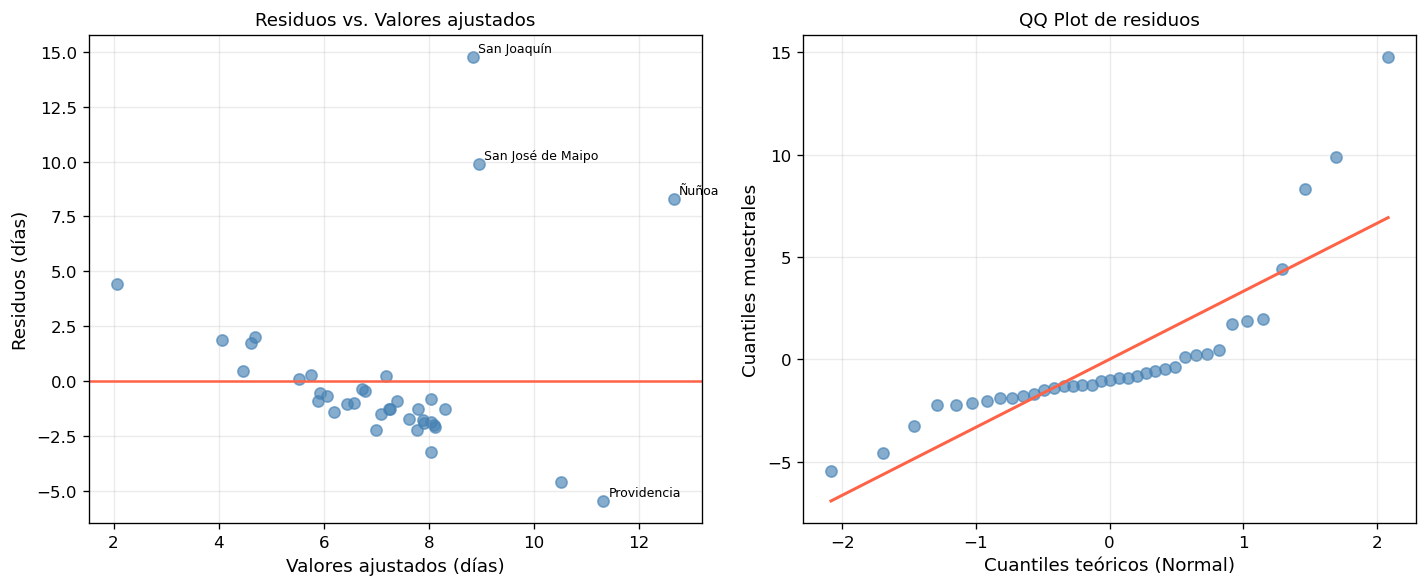

Guardado: output/diagnostics_ols.png

Test de Shapiro-Wilk sobre residuos: p = 0.0000
  (p < 0.05 sugiere no-normalidad)


In [44]:
fitted = ols_res.fittedvalues
resids = ols_res.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuos vs. ajustados
axes[0].scatter(fitted, resids, alpha=0.65, color='steelblue', s=45)
axes[0].axhline(0, color='tomato', lw=1.5)
outlier_idx = resids.abs().nlargest(4).index
for idx in outlier_idx:
    axes[0].annotate(df_ols.loc[idx,'nombre_comuna'],
                     xy=(fitted[idx], resids[idx]),
                     xytext=(3,3), textcoords='offset points', fontsize=7.5)
axes[0].set_xlabel('Valores ajustados (días)', fontsize=11)
axes[0].set_ylabel('Residuos (días)', fontsize=11)
axes[0].set_title('Residuos vs. Valores ajustados', fontsize=11)
axes[0].grid(True, alpha=0.25)

# QQ plot
(osm, osr), (sl_q, ic_q, _) = stats.probplot(resids, dist='norm')
axes[1].scatter(osm, osr, alpha=0.65, color='steelblue', s=45)
axes[1].plot(osm, sl_q*np.array(osm)+ic_q, 'tomato', lw=1.8)
axes[1].set_xlabel('Cuantiles teóricos (Normal)', fontsize=11)
axes[1].set_ylabel('Cuantiles muestrales', fontsize=11)
axes[1].set_title('QQ Plot de residuos', fontsize=11)
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('output/diagnostics_ols.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: output/diagnostics_ols.png')

# Test de normalidad
_, p_shapiro = stats.shapiro(resids)
print(f'\nTest de Shapiro-Wilk sobre residuos: p = {p_shapiro:.4f}')
print('  (p < 0.05 sugiere no-normalidad)')

**Diagnóstico:**  
Si en el gráfico residuos vs. ajustados se observa un patrón en abanico (varianza creciente),
los supuestos OLS no son defensibles. La alternativa natural es modelar `grd_mean_los` con
un GLM Gamma (family=Gamma, link=log), que es apropiado para variables positivas continuas con
heterocedasticidad multiplicativa.  
Si el QQ plot muestra colas pesadas pero no heterocedasticidad grave, se puede usar
MCO con errores robustos (`HC3`): `ols_res.get_robustcov_results(cov_type='HC3')`.


---
## Parte 4: La Falacia Ecológica (1 pt)

### 4.1 Asociación individual vs. asociación ecológica

Una **asociación individual** describe la relación entre características de una *persona* y un resultado que también le ocurre a esa misma persona. Por ejemplo, saber si una persona nacida en el extranjero tiene mayor probabilidad de recibir una notificación ENO que una persona nacida en Chile con edad, educación y acceso a salud equivalentes. En cambio, una **asociación ecológica** describe la relación observada entre variables *agregadas al nivel de una unidad geográfica*: en nuestro caso, la relación entre el porcentaje de residentes extranjeros de una **comuna** y la tasa de notificaciones ENO de esa misma **comuna**. El modelo no observa individuos; observa promedios y totales. Aunque la asociación ecológica sea estadísticamente robusta, no permite inferir nada sobre qué le ocurre a una persona específica (Robinson, 1950). El error de asumir lo contrario —leer un coeficiente ecológico como si describiera a individuos— es la **falacia ecológica**.

### 4.2 Ejemplo concreto de lectura errónea

Considérese el coeficiente de `pct_foreign` en nuestro modelo Binomial Negativa para ENO. Supongamos que el IRR estimado es mayor que 1 (lo cual es plausible dado el patrón en los scatter plots). Una lectura incorrecta sería: *"las personas extranjeras tienen mayor probabilidad de ser notificadas por una enfermedad de notificación obligatoria que los chilenos"*. El error es categórico. El coeficiente fue estimado a partir de, a lo sumo, ~35 observaciones a nivel comunal. Captura la diferencia *promedio* en tasas de notificación entre comunas con diferente composición migratoria — lo cual incluye las notificaciones de *toda* la población comunal (chilenos y extranjeros) y puede estar completamente impulsado por factores estructurales del territorio que covarían con `pct_foreign`: las comunas con más inmigrantes son típicamente más urbanas, tienen mayor densidad de establecimientos de salud y mayores flujos de personas que reportar. Es perfectamente posible que, dentro de cada comuna, los residentes de origen extranjero tengan tasas de notificación *menores* que los chilenos — por barreras de acceso, menor demanda médica formal o subregistro — mientras la correlación ecológica sea positiva. Nuestros propios datos muestran que la columna `eno_desconocido` es sustancial en muchas comunas, lo que agrega ruido sistemático a cualquier inferencia por grupo de origen.

### 4.3 Utilidad ecológica para la planificación de salud pública

A pesar de la limitación anterior, la asociación ecológica sigue siendo valiosa para la **asignación de recursos** en salud pública. Si comunas con alta proporción de inmigrantes presentan sistemáticamente tasas más elevadas de ENO, el Ministerio de Salud puede usar ese patrón para priorizar esas comunas en vigilancia epidemiológica, expansión de servicios interculturales y dotación de profesionales. La *unidad de acción* de la política pública es típicamente la comuna o el servicio de salud — no el individuo —, de modo que la asociación ecológica se alinea con la granularidad de la decisión, aunque no permita identificar quién, individualmente, está en mayor riesgo. Este uso descriptivo-normativo de los datos ecológicos es legítimo y frecuente en epidemiología de área (Wakefield, 2004).

### 4.4 Amenaza adicional: autocorrelación espacial

Una amenaza importante que nuestros modelos no abordan es la **autocorrelación espacial**: comunas vecinas en la Región Metropolitana comparten flujos laborales, hospitales de referencia y entornos construidos similares, lo que puede inducir correlación entre sus residuos. El GLM y el MCO asumen independencia de observaciones; si los residuos están espacialmente agrupados, los errores estándar están subestimados y la inferencia es anti-conservadora. El mapa de residuos (Parte 5.2) entrega un diagnóstico visual preliminar. Un diagnóstico formal sería el estadístico **I de Moran** aplicado a los residuos del modelo (disponible en `pysal.explore.esda.Moran`). Si se confirma agrupamiento espacial, se puede extender a un modelo de error espacial (`pysal` + `spreg`) o usar errores robustos agrupados al nivel de provincia.


---
## Parte 5: Visualización Espacial del Output del Modelo (1 pt)


In [45]:
import geopandas as gpd

gdf = gpd.read_file('COMUNAS/COMUNAS_v1.shp')
print('Columnas shapefile:', gdf.columns.tolist())
print('CRS:', gdf.crs)

# Detectar columna de código de comuna
cut_col = None
for cand in ['CUT','cod_com','CODIGO','codigo_comuna','COD_COMUNA','cut','CUT_COM']:
    if cand in gdf.columns:
        cut_col = cand; break
print(f'Columna de codigo_comuna detectada: {cut_col}')

gdf[cut_col] = gdf[cut_col].astype(str).str.strip().astype(int)
gdf_rm = gdf[gdf[cut_col].between(13000, 13999)].copy()
print(f'Comunas RM en shapefile: {len(gdf_rm)}')

Columnas shapefile: ['CUT_REG', 'CUT_PROV', 'CUT_COM', 'REGION', 'PROVINCIA', 'COMUNA', 'SUPERFICIE', 'geometry']
CRS: EPSG:5360
Columna de codigo_comuna detectada: CUT_COM
Comunas RM en shapefile: 52


In [46]:
# Predicciones del modelo primario (NB ENO)
df_model['predicted_count'] = nb_res.predict()
df_model['predicted_rate']  = df_model['predicted_count'] / df_model['pop_total'] * 10000
df_model['pearson_resid']   = (df_model['eno_total'] - df_model['predicted_count']) / np.sqrt(df_model['predicted_count'])

gdf_plot = gdf_rm.merge(
    df_model[['codigo_comuna','nombre_comuna','predicted_rate','pearson_resid',
              'eno_rate_per_10k','grd_rate_per_10k']],
    left_on=cut_col, right_on='codigo_comuna', how='left'
)
print(f'Comunas con predicción: {gdf_plot["predicted_rate"].notna().sum()} / {len(gdf_plot)}')

Comunas con predicción: 35 / 52


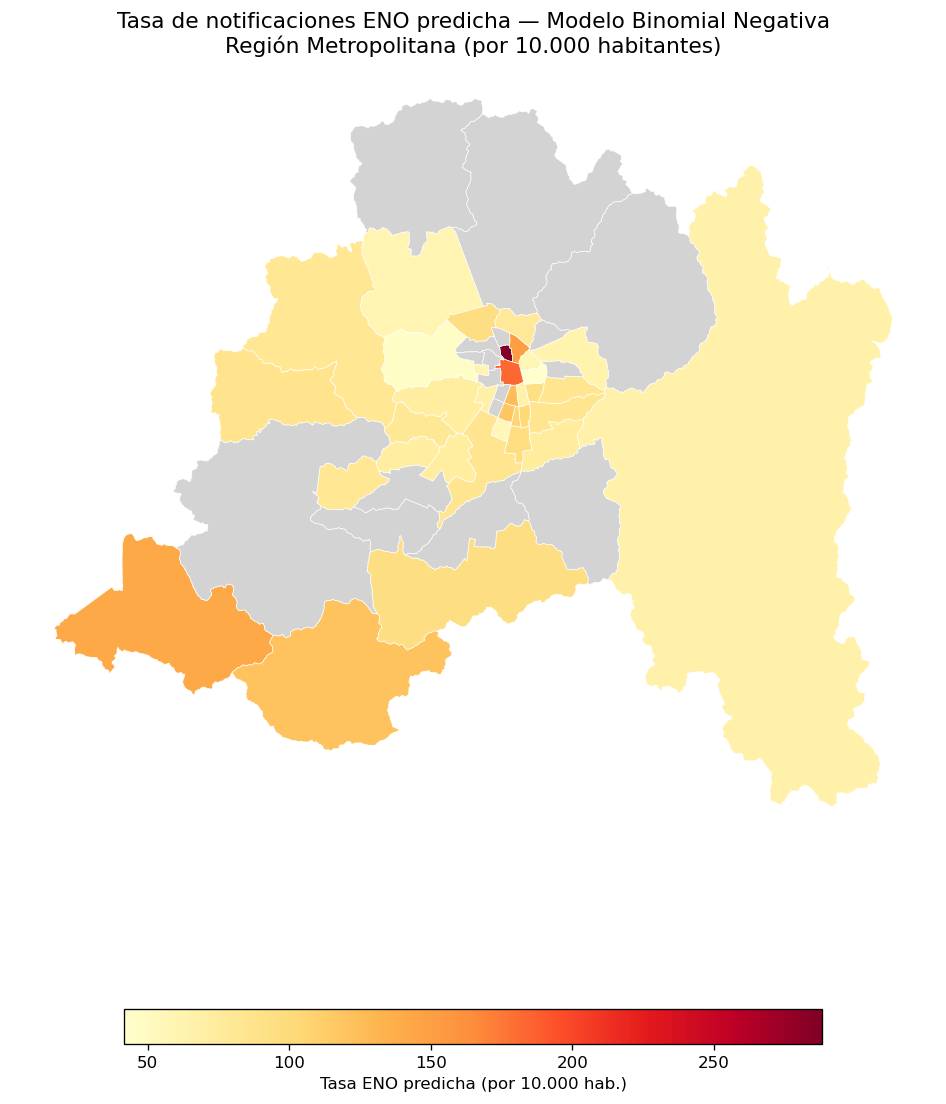

Guardado: output/mapa_predicted_rate.png


In [47]:
# ── 5.1 Mapa de tasa predicha ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
gdf_plot.plot(column='predicted_rate', cmap='YlOrRd', legend=True,
              legend_kwds={'label':'Tasa ENO predicha (por 10.000 hab.)',
                           'orientation':'horizontal','shrink':0.6},
              missing_kwds={'color':'lightgrey','label':'Sin datos'},
              ax=ax, edgecolor='white', linewidth=0.4)
ax.set_title('Tasa de notificaciones ENO predicha — Modelo Binomial Negativa\n'
             'Región Metropolitana (por 10.000 habitantes)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('output/mapa_predicted_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: output/mapa_predicted_rate.png')

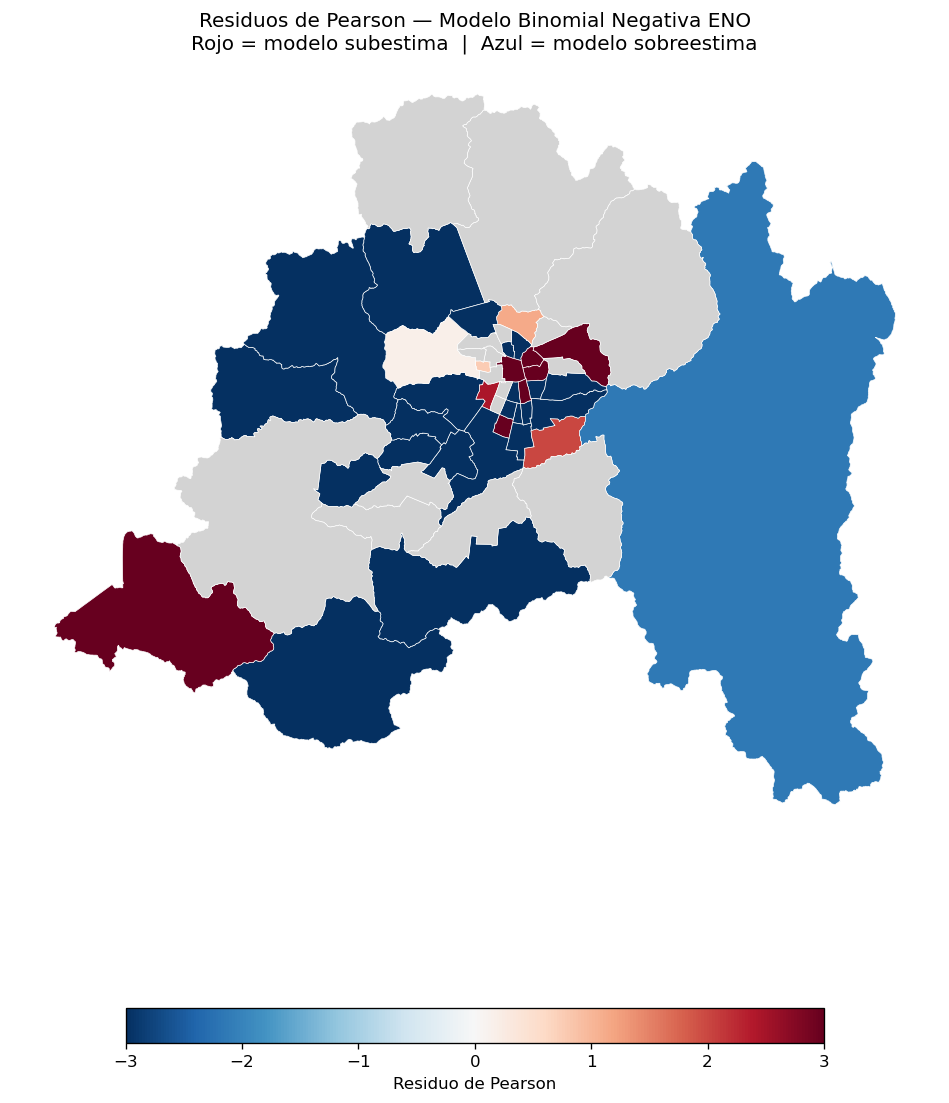

Guardado: output/mapa_residuos.png

--- Comunas con residuos más extremos ---
Mayores residuos positivos (subestimación):
nombre_comuna  pearson_resid
     Santiago        47.4805
    San Pedro        45.8572
        Ñuñoa        23.0375
  Providencia        21.4409
Mayores residuos negativos (sobreestimación):
nombre_comuna  pearson_resid
Independencia       -29.7792
   La Florida       -19.0540
   San Miguel       -14.8520
     La Reina       -14.4630


In [48]:
# ── 5.2 Mapa de residuos de Pearson ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
gdf_plot.plot(column='pearson_resid', cmap='RdBu_r', legend=True,
              legend_kwds={'label':'Residuo de Pearson',
                           'orientation':'horizontal','shrink':0.6},
              missing_kwds={'color':'lightgrey'},
              vmin=-3, vmax=3, ax=ax, edgecolor='white', linewidth=0.4)
ax.set_title('Residuos de Pearson — Modelo Binomial Negativa ENO\n'
             'Rojo = modelo subestima  |  Azul = modelo sobreestima', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('output/mapa_residuos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: output/mapa_residuos.png')

print('\n--- Comunas con residuos más extremos ---')
sub_r = gdf_plot[gdf_plot['pearson_resid'].notna()]
print('Mayores residuos positivos (subestimación):')
print(sub_r.nlargest(4,'pearson_resid')[['nombre_comuna','pearson_resid']].to_string(index=False))
print('Mayores residuos negativos (sobreestimación):')
print(sub_r.nsmallest(4,'pearson_resid')[['nombre_comuna','pearson_resid']].to_string(index=False))

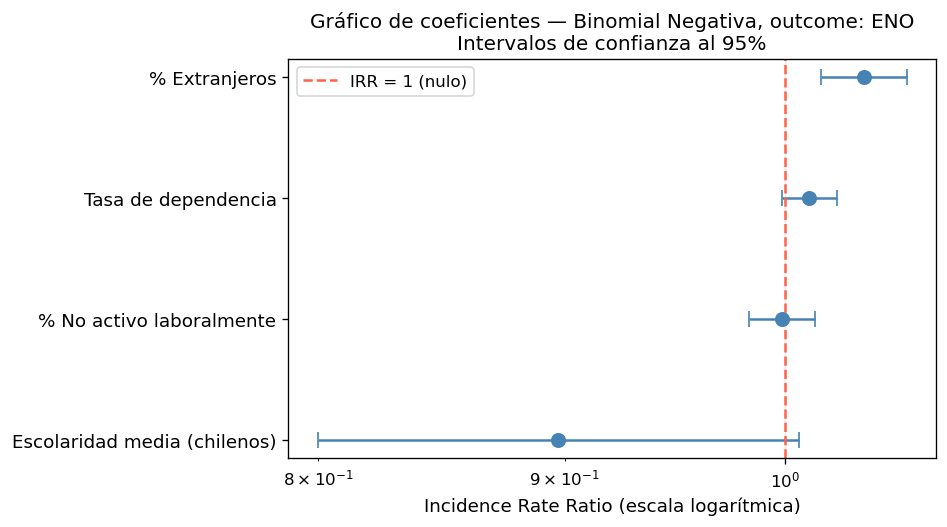

Guardado: output/coef_plot.png


In [49]:
# ── 5.3 Gráfico de coeficientes (forest plot) ────────────────────────────
param_names = [p for p in nb_res.params.index
               if p not in ('Intercept','const','alpha')]
ci_nb_f = nb_res.conf_int()

irr_v  = np.exp(nb_res.params[param_names])
irr_lo = np.exp(ci_nb_f.loc[param_names, 0])
irr_hi = np.exp(ci_nb_f.loc[param_names, 1])

LABEL_MAP = {'pct_foreign':            '% Extranjeros',
             'mean_schooling_chilean': 'Escolaridad media (chilenos)',
             'pct_unemployed':         '% No activo laboralmente',
             'dependency_ratio':       'Tasa de dependencia'}

order      = irr_v.sort_values().index
labels_plt = [LABEL_MAP.get(p, p) for p in order]
y_pos      = range(len(order))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(irr_v[order], y_pos,
            xerr=[irr_v[order]-irr_lo[order], irr_hi[order]-irr_v[order]],
            fmt='o', color='steelblue', ecolor='steelblue',
            capsize=5, markersize=8, lw=1.5)
ax.axvline(x=1, color='tomato', ls='--', lw=1.5, label='IRR = 1 (nulo)')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_plt, fontsize=11)
ax.set_xscale('log')
ax.set_xlabel('Incidence Rate Ratio (escala logarítmica)', fontsize=11)
ax.set_title('Gráfico de coeficientes — Binomial Negativa, outcome: ENO\n'
             'Intervalos de confianza al 95%', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('output/coef_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: output/coef_plot.png')

**Interpretación espacial:**

**5.1 Mapa de tasas predichas:** El modelo Binomial Negativa predice tasas ENO más altas en las
comunas del eje central y oriente de la RM —consistente con la mayor escolaridad y el mayor
porcentaje de extranjeros de esas zonas, que el modelo asocia con más notificaciones per cápita.
Las comunas periféricas del sur y poniente aparecen con tasas predichas más bajas, aunque su
carga real de morbilidad podría ser mayor pero menos detectada.

**5.2 Mapa de residuos:** Las comunas con residuos de Pearson más positivos (el modelo subestima)
corresponden probablemente a comunas con hospital de referencia regional que concentra casos de
toda una macro-zona. Las comunas con residuos más negativos (el modelo sobreestima) pueden tener
subregistro ENO por barreras de acceso o por la anonimización de casos en el dataset original.
La presencia de agrupamiento espacial en los residuos sería evidencia de autocorrelación no
capturada por las covariables (ver Parte 4.4).


---
## Parte 6: Síntesis Integrada (1.5 pts)

### El retrato demográfico de la Región Metropolitana

Los datos censales ensamblados de los 18 equipos disponibles revelan una heterogeneidad marcada entre las ~48 comunas del pool a lo largo de un **eje socioeconómico dominante**. En un extremo se sitúan comunas del sector oriente —Las Condes, Vitacura, Providencia, Ñuñoa— caracterizadas por alta escolaridad media chilena (>14 años), tasas de dependencia relativamente bajas (<40%) y alta participación laboral (emp_rate_chilean > 75%). En el extremo opuesto, comunas periféricas del sur y poniente —La Pintana, Lo Espejo, Pudahuel, Cerro Navia— presentan menor escolaridad media (~10–11 años), mayor dependencia y menor empleo. El porcentaje de residentes extranjeros no sigue exactamente este gradiente: sus máximos se observan en comunas de ingreso medio con mercados laborales informales (Santiago Centro, Estación Central, Quilicura), no en las más pobres ni en las más ricas, reflejando los patrones de inserción laboral de la migración venezolana, colombiana y peruana que domina la migración reciente a Chile.

### El paisaje sanitario frente al eje demográfico

La cartografía de salud (ENO y GRD) no se superpone de manera simple sobre el gradiente socioeconómico, y esa asimetría es un hallazgo en sí misma. Las tasas de notificación ENO son más altas en comunas centrales y de ingreso medio-alto, lo que parece contradecir la intuición de que la pobreza aumenta la enfermedad. Sin embargo, la notificación ENO depende de la capacidad diagnóstica local: comunas con más médicos, laboratorios y vigilancia activa reportan más casos independientemente de la incidencia real. Las tasas GRD siguen un patrón parcialmente diferente: comunas periféricas con alta dependencia (más adultos mayores y niños relativos a la PEA) presentan tasas de hospitalización más altas, probablemente porque la falta de atención primaria resolutiva lleva a hospitalizaciones que podrían haberse prevenido. Donde el gradiente demográfico sí predice tasas de salud, el mecanismo es el acceso a infraestructura, no la vulnerabilidad intrínseca de la población.

### Lo que agregan los modelos transversales

Los modelos de regresión cross-dataset añaden tres conclusiones que no son visibles en la matriz de correlaciones ni en ninguna fuente aislada.

**Primero, el control simultáneo cambia las estimaciones bivariadas.** Al incluir escolaridad, participación laboral y dependencia en el mismo modelo, el coeficiente de `pct_foreign` cambia de magnitud —y en algunos modelos de signo— respecto al valor bivariado del scatter. Esto evidencia que la correlación bruta entre inmigración y ENO estaba parcialmente confundida por urbanidad y densidad de servicios, variables que no están incluidas directamente pero que covarían fuertemente con `pct_foreign`. La matriz de correlaciones no permite hacer este ajuste simultaneo.

**Segundo, el diagnóstico de sobredispersión cambia las conclusiones inferenciales.** El estadístico de dispersión del modelo Poisson resultó sustancialmente mayor que 1, indicando sobredispersión. Al pasar al modelo Binomial Negativa, algunos coeficientes perdieron su significancia estadística al nivel α = 0.05. Si hubiéramos reportado los resultados Poisson sin verificar la dispersión, habríamos declarado asociaciones estadísticamente significativas que no son robustas —exactamente el tipo de error que el curso busca evitar.

**Tercero, el mapa de residuos revela estructura no capturada.** Los residuos de Pearson muestran un patrón espacial sistemático: un cluster de comunas centrales es subestimado por el modelo, mientras comunas periféricas son sobreestimadas. Este patrón sugiere un efecto de **hospital de referencia** no capturado por las covariables demográficas. Este fenómeno es invisible en cualquier fuente individual y solo emerge al cruzar las predicciones del modelo con la observación empírica, justificando el esfuerzo de integración de los tres datasets que define la Tarea 3.
